In [1]:
import sys
sys.path.append('../src')

from generate_data import generate_ran_kpi_data

df = generate_ran_kpi_data()
df.to_csv('../data/ran_kpi_data.csv', index=False)

print(df.shape)
print(df['anomaly_type'].value_counts())
df.head()

(5000, 10)
anomaly_type
normal          4750
failure           91
interference      83
congestion        76
Name: count, dtype: int64


,timestamp,cell_id,rsrp,sinr,prb_utilization,throughput_mbps,packet_loss,latency_ms,is_anomaly,anomaly_type
0,2024-01-06 05:05:00,CELL_015,-99.789086,15.573459,50.508961,32.436593,0.604780,19.125739,0,normal
1,2024-01-09 23:30:00,CELL_006,-86.895746,11.694702,63.785108,27.884311,0.717470,11.409778,0,normal
2,2024-01-10 05:05:00,CELL_011,-90.485694,14.884030,34.831206,18.373811,0.621009,23.793242,0,normal
3,2024-01-04 15:55:00,CELL_018,-89.484361,14.681066,58.691334,25.098682,0.494870,15.907032,0,normal
4,2024-01-03 10:45:00,CELL_019,-94.977565,19.245501,33.076043,21.965390,0.628417,11.847482,0,normal


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/ran_kpi_data.csv')

print(df.describe().round(2))

          rsrp     sinr  prb_utilization  throughput_mbps  packet_loss  \
count  5000.00  5000.00          5000.00          5000.00      5000.00   
mean    -85.60    14.63            45.83            24.70         0.64   
std       8.93     4.58            12.97             6.43         1.07   
min    -127.75    -8.09             3.12             0.09         0.00   
25%     -90.82    11.95            37.15            20.71         0.37   
50%     -85.21    14.83            45.29            24.86         0.51   
75%     -79.66    17.56            53.42            29.03         0.65   
max     -55.74    29.41           100.00            48.42        14.67   

       latency_ms  is_anomaly  
count     5000.00     5000.00  
mean        20.92        0.05  
std          9.17        0.22  
min          4.88        0.00  
25%         17.29        0.00  
50%         19.95        0.00  
75%         22.85        0.00  
max        125.16        1.00  


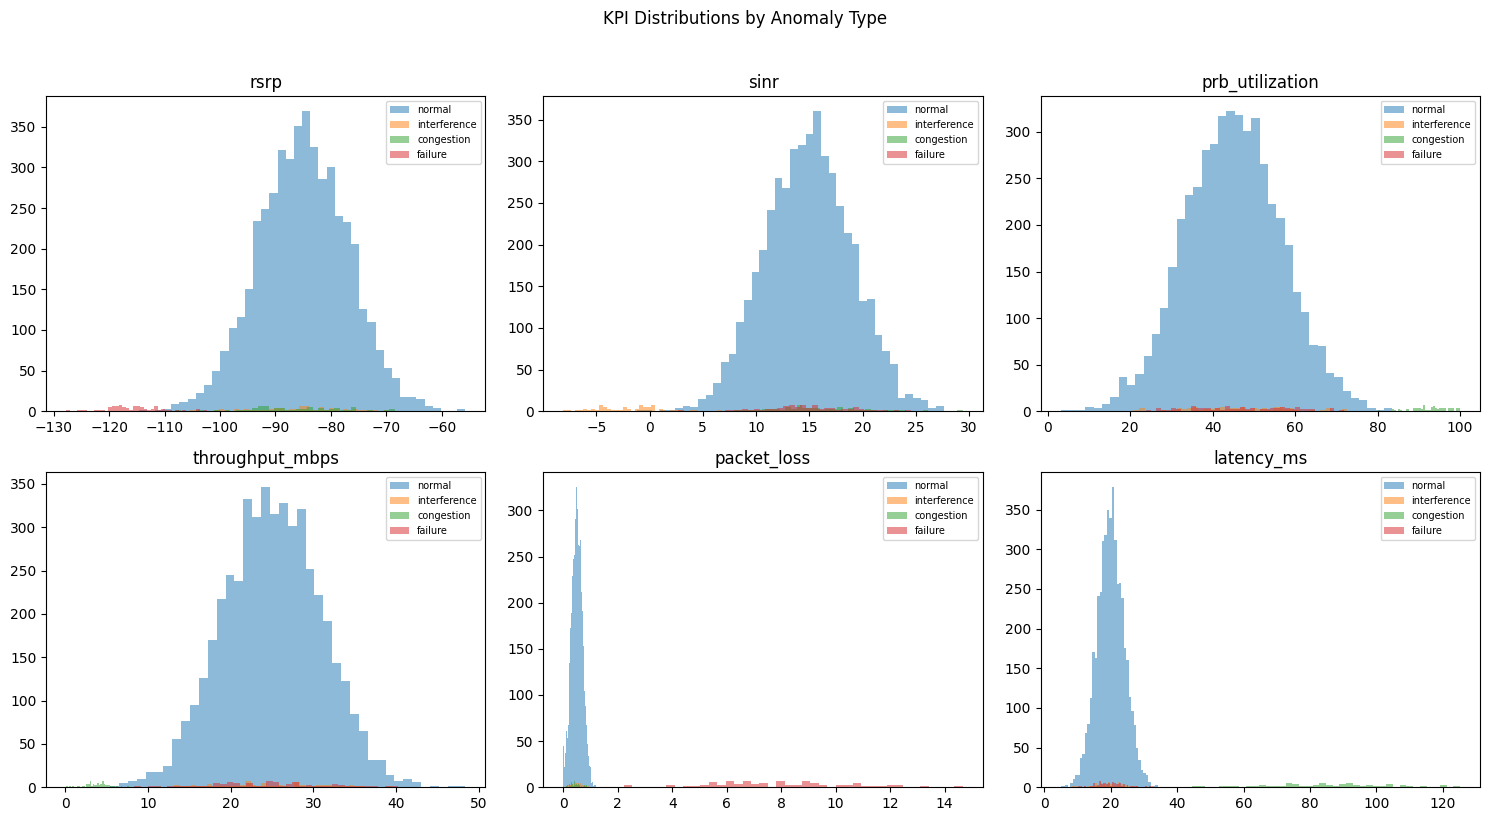

In [3]:
kpis = ['rsrp', 'sinr', 'prb_utilization', 'throughput_mbps', 'packet_loss', 'latency_ms']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, kpi in enumerate(kpis):
    for atype in ['normal', 'interference', 'congestion', 'failure']:
        subset = df[df['anomaly_type'] == atype][kpi]
        axes[i].hist(subset, bins=40, alpha=0.5, label=atype)
    axes[i].set_title(kpi)
    axes[i].legend(fontsize=7)

plt.suptitle('KPI Distributions by Anomaly Type', y=1.02)
plt.tight_layout()
plt.savefig('../models/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

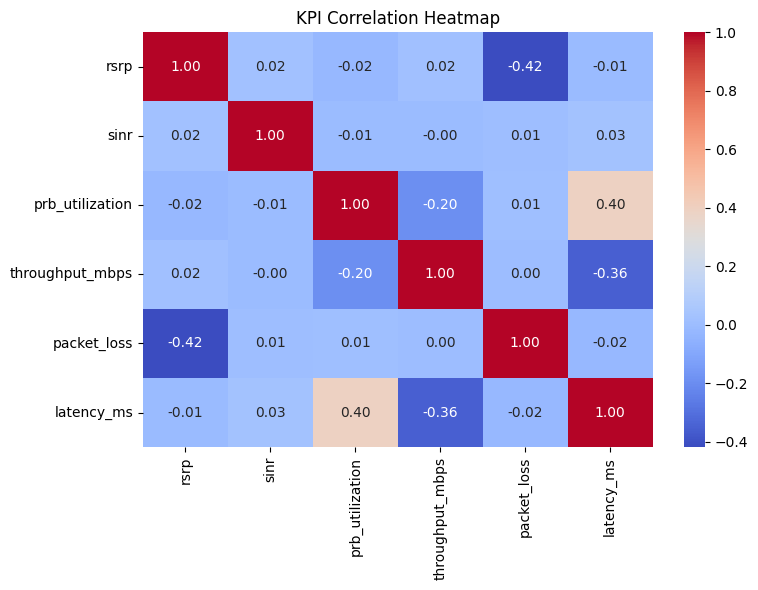

In [4]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[kpis].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('KPI Correlation Heatmap')
plt.tight_layout()
plt.show()

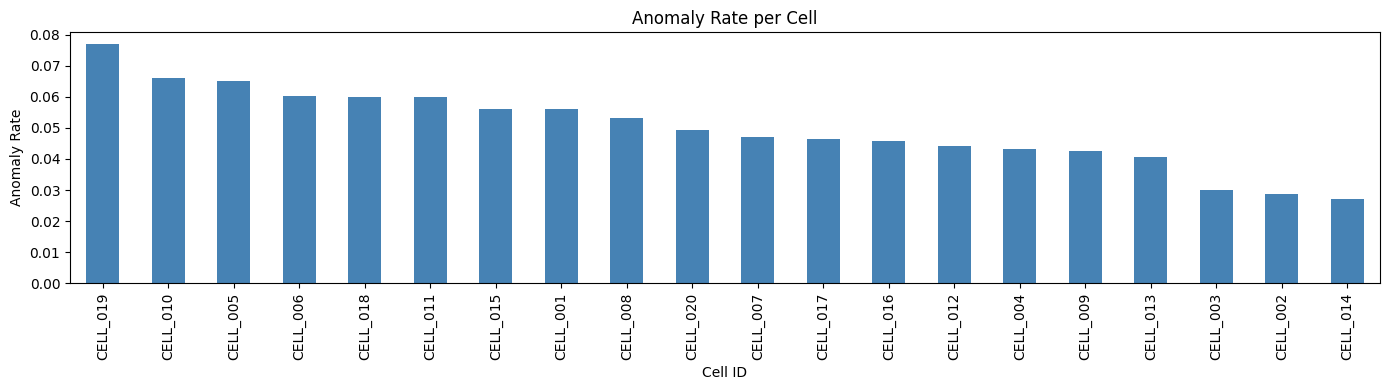

In [5]:
cell_anomaly = df.groupby('cell_id')['is_anomaly'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 4))
cell_anomaly.plot(kind='bar', color='steelblue')
plt.title('Anomaly Rate per Cell')
plt.xlabel('Cell ID')
plt.ylabel('Anomaly Rate')
plt.tight_layout()
plt.show()